In [82]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pickle

In [83]:
df=pd.read_csv('..//data//Raw//testdataset_3.csv')
df.head()

,sample_id,label,timestep,flex1,flex2,flex3,flex4,flex5,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z
0,2,salam,0,4031,3400,3772,3530,3743,3949,1417,-143,292,415,-142
1,2,salam,1,4053,3407,3803,3545,3737,3993,932,-592,210,236,-85
2,2,salam,2,4045,3388,3801,3541,3752,3998,1205,-530,-1384,-450,146
3,2,salam,3,4041,3391,3793,3547,3757,4517,1931,-917,195,-599,-230
4,2,salam,4,4037,3399,3800,3551,3748,4605,2428,-2217,270,-1203,-827


In [84]:
# ============================================
# 2. CONVERT TO SAMPLES (20 timesteps × 11 features)
# ============================================

# Define feature columns
feature_cols = ['flex1', 'flex2', 'flex3', 'flex4', 'flex5', 
                'accel_x', 'accel_y', 'accel_z', 
                'gyro_x', 'gyro_y', 'gyro_z']

# Create samples
X_samples = []
y_samples = []

for sample_id in df['sample_id'].unique():
    # Get all data for this sample
    sample_data = df[df['sample_id'] == sample_id]
    
    # Sort by timestep to maintain order (0-19)
    sample_data = sample_data.sort_values('timestep')
    
    # Extract features (20 timesteps × 11 features)
    features = sample_data[feature_cols].values  # Shape: (20, 11)
    
    # Get label
    label = sample_data['label'].iloc[0]
    
    X_samples.append(features)
    y_samples.append(label)

# Convert to numpy arrays
X_samples = np.array(X_samples)  # Shape: (220, 20, 11)
y_samples = np.array(y_samples)  # Shape: (220,)

print(f"\nX_samples shape: {X_samples.shape}")  # (220, 20, 11)
print(f"y_samples shape: {y_samples.shape}")    # (220,)
print(f"Number of classes: {len(np.unique(y_samples))}")


X_samples shape: (11, 20, 11)
y_samples shape: (11,)
Number of classes: 11


In [85]:
y_samples

array(['salam', 'apni', 'kemon', 'achen', 'ami', 'valo', 'achi', 'apnar',
       'naam', 'kii', 'dhonnobad'], dtype='<U9')

In [86]:
#label encoding the y_samples
label_encoder = LabelEncoder()
y_samples_encoded = label_encoder.fit_transform(y_samples)


In [87]:
# ============================================
# 5. SCALING - RESHAPE, SCALE, RESHAPE BACK
# ============================================

scaler = StandardScaler()

# Get shapes
n_train_samples, n_timesteps, n_features = X_samples.shape
n_test_samples, _, _ = X_samples.shape

print(f"\nScaling shapes:")
print(f"  Train: {n_train_samples} samples × {n_timesteps} timesteps × {n_features} features")
print(f"  Test: {n_test_samples} samples × {n_timesteps} timesteps × {n_features} features")

# Reshape to 2D for scaling: (samples * timesteps, features)
X_test_2d = X_samples.reshape(-1, n_features)    # Shape: (880, 11)



# Fit scaler on training data
X_test_scaled_2d = scaler.fit_transform(X_test_2d)

# Reshape back to 3D
X_test_scaled = X_test_scaled_2d.reshape(n_test_samples, n_timesteps, n_features)


print(f"Scaled X_test shape: {X_test_scaled.shape}")

X_test_flat = X_test_scaled.reshape(X_test_scaled.shape[0], -1)


Scaling shapes:
  Train: 11 samples × 20 timesteps × 11 features
  Test: 11 samples × 20 timesteps × 11 features
Scaled X_test shape: (11, 20, 11)


In [88]:
#import the XGBoost model from the Models directory
with open('../Models/xgboost_model.pkl', 'rb') as f:
    final_model = pickle.load(f)

In [89]:
y_pred = final_model.predict(X_test_flat)

#convert the predicted labels back to their original string representation
y_pred_labels = [label_encoder.inverse_transform([pred])[0] for pred in y_pred]
print(f"\nPredicted labels: {y_pred_labels}")

#show the predicted labels confidence scores and only show the confidence scores for the predicted labels 
y_pred_proba = final_model.predict_proba(X_test_flat)
predicted_confidences = [y_pred_proba[i][pred] for i, pred
    in enumerate(y_pred)]
predicted_confidences_pct = [conf * 100 for conf in predicted_confidences]

print("\nPredicted confidences:")
for label, conf in zip(y_pred_labels, predicted_confidences_pct):
    print(f"{label}: {conf:.2f}%")




Predicted labels: [np.str_('salam'), np.str_('ami'), np.str_('kemon'), np.str_('achen'), np.str_('ami'), np.str_('valo'), np.str_('achi'), np.str_('apnar'), np.str_('naam'), np.str_('valo'), np.str_('apnar')]

Predicted confidences:
salam: 53.88%
ami: 17.67%
kemon: 62.70%
achen: 73.12%
ami: 49.88%
valo: 34.59%
achi: 63.76%
apnar: 64.76%
naam: 53.88%
valo: 30.68%
apnar: 35.01%


In [90]:
#accuracy score
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_samples_encoded, y_pred)
print(f"\nAccuracy: {accuracy*100:.2f}%")



Accuracy: 72.73%


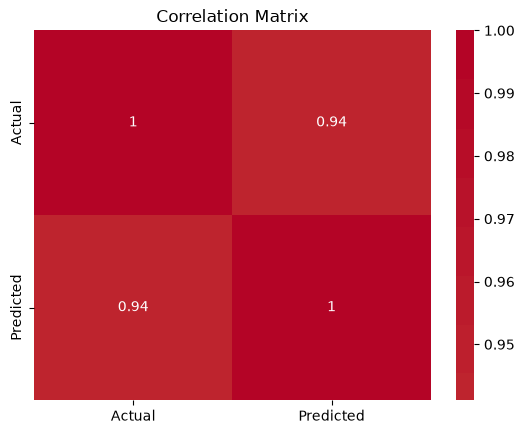

In [91]:
#corr matrix to check the correlation between the predicted and actual labels
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = pd.DataFrame({
    'Actual': y_samples_encoded,
    'Predicted': y_pred
}).corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

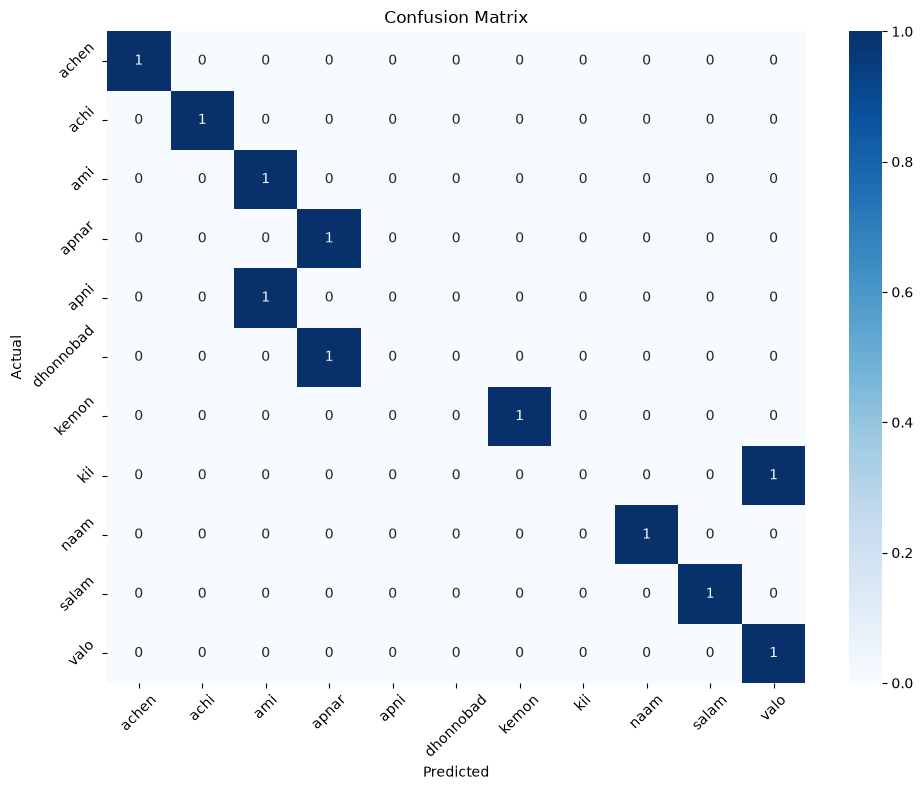

In [92]:
# Cell 3: Confusion Matrix
from sklearn.metrics import confusion_matrix


plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_samples_encoded, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()